# RANDOM FOREST REGRESSOR ALGORITHEM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the datasets
df=pd.read_csv('IPL_FINAL.csv')

df.head()

,batting_team,bowling_team,venue,pitch_condition,temperature,humidity,overs_completed,runs_scored,wickets_lost,run_rate,last_5_overs_runs,striker_strike_rate,non_striker_strike_rate,partnership_runs,boundaries_hit,extras_conceded,predicted_total
0,Lucknow Super Giants,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,bowling friendly,37,67,5.4,33,0,5.69,18,69.86,63.35,26,2,14,122
1,Rajasthan Royals,Lucknow Super Giants,Ekana Cricket Stadium,flat,38,51,5.5,57,1,10.07,36,121.23,126.37,37,5,13,215
2,Gujarat Titans,Lucknow Super Giants,M. Chinnaswamy Stadium,flat,36,38,19.6,172,4,8.94,45,108.36,112.73,29,11,13,182
3,Mumbai Indians,Lucknow Super Giants,Ekana Cricket Stadium,balanced,31,32,14.0,104,4,6.96,38,94.61,72.98,56,7,6,145
4,Chennai Super Kings,Punjab Kings,Arun Jaitley Stadium,dry,25,66,13.9,98,4,7.17,40,88.09,87.93,14,6,12,147


In [3]:
df.columns

Index(['batting_team', 'bowling_team', 'venue', 'pitch_condition',
       'temperature', 'humidity', 'overs_completed', 'runs_scored',
       'wickets_lost', 'run_rate', 'last_5_overs_runs', 'striker_strike_rate',
       'non_striker_strike_rate', 'partnership_runs', 'boundaries_hit',
       'extras_conceded', 'predicted_total'],
      dtype='object')

In [4]:
df=df.dropna()

In [5]:
df['batting_team'].unique()

array(['Lucknow Super Giants', 'Rajasthan Royals', 'Gujarat Titans',
       'Mumbai Indians', 'Chennai Super Kings', 'Sunrisers Hyderabad',
       'Punjab Kings', 'Delhi Capitals', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders'], dtype=object)

In [6]:
df['pitch_condition'].unique()

array(['bowling friendly', 'flat', 'balanced', 'dry', 'green', 'slow',
       'batting friendly'], dtype=object)

In [7]:
df['venue'].unique()

array(['Rajiv Gandhi International Stadium', 'Ekana Cricket Stadium',
       'M. Chinnaswamy Stadium', 'Arun Jaitley Stadium',
       'M. A. Chidambaram Stadium', 'Wankhede Stadium', 'PCA Stadium',
       'Narendra Modi Stadium', 'Sawai Mansingh Stadium', 'Eden Gardens'],
      dtype=object)

In [8]:
df['batting_team'].unique()

array(['Lucknow Super Giants', 'Rajasthan Royals', 'Gujarat Titans',
       'Mumbai Indians', 'Chennai Super Kings', 'Sunrisers Hyderabad',
       'Punjab Kings', 'Delhi Capitals', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders'], dtype=object)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   batting_team             5000 non-null   object 
 1   bowling_team             5000 non-null   object 
 2   venue                    5000 non-null   object 
 3   pitch_condition          5000 non-null   object 
 4   temperature              5000 non-null   int64  
 5   humidity                 5000 non-null   int64  
 6   overs_completed          5000 non-null   float64
 7   runs_scored              5000 non-null   int64  
 8   wickets_lost             5000 non-null   int64  
 9   run_rate                 5000 non-null   float64
 10  last_5_overs_runs        5000 non-null   int64  
 11  striker_strike_rate      5000 non-null   float64
 12  non_striker_strike_rate  5000 non-null   float64
 13  partnership_runs         5000 non-null   int64  
 14  boundaries_hit          

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

var = ['batting_team','bowling_team','venue','pitch_condition']
  
for i in var:
    df[i] = le.fit_transform(df[i]).astype(int)

In [11]:
df['batting_team'].unique()

array([4, 7, 2, 5, 0, 9, 6, 1, 8, 3])

In [12]:
df['venue'].unique()

array([7, 2, 4, 0, 3, 9, 6, 5, 8, 1])

In [13]:
df['pitch_condition'].unique()

array([2, 4, 0, 3, 5, 6, 1])

In [14]:
df.head()

,batting_team,bowling_team,venue,pitch_condition,temperature,humidity,overs_completed,runs_scored,wickets_lost,run_rate,last_5_overs_runs,striker_strike_rate,non_striker_strike_rate,partnership_runs,boundaries_hit,extras_conceded,predicted_total
0,4,9,7,2,37,67,5.4,33,0,5.69,18,69.86,63.35,26,2,14,122
1,7,4,2,4,38,51,5.5,57,1,10.07,36,121.23,126.37,37,5,13,215
2,2,4,4,4,36,38,19.6,172,4,8.94,45,108.36,112.73,29,11,13,182
3,5,4,2,0,31,32,14.0,104,4,6.96,38,94.61,72.98,56,7,6,145
4,0,6,0,3,25,66,13.9,98,4,7.17,40,88.09,87.93,14,6,12,147


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   batting_team             5000 non-null   int64  
 1   bowling_team             5000 non-null   int64  
 2   venue                    5000 non-null   int64  
 3   pitch_condition          5000 non-null   int64  
 4   temperature              5000 non-null   int64  
 5   humidity                 5000 non-null   int64  
 6   overs_completed          5000 non-null   float64
 7   runs_scored              5000 non-null   int64  
 8   wickets_lost             5000 non-null   int64  
 9   run_rate                 5000 non-null   float64
 10  last_5_overs_runs        5000 non-null   int64  
 11  striker_strike_rate      5000 non-null   float64
 12  non_striker_strike_rate  5000 non-null   float64
 13  partnership_runs         5000 non-null   int64  
 14  boundaries_hit          

In [16]:
x = df.drop(labels='predicted_total', axis=1)
y = df.loc[:,'predicted_total']

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print("NUMBER OF TRAIN DATASET    : ", len(x_train))
print("NUMBER OF TEST DATASET      : ", len(x_test))
print("TOTAL NUMBER OF DATASET    : ", len(x_train)+len(x_test))

NUMBER OF TRAIN DATASET    :  4000
NUMBER OF TEST DATASET      :  1000
TOTAL NUMBER OF DATASET    :  5000


In [18]:
print("NUMBER OF TRAIN DATASET    : ", len(y_train))
print("NUMBER OF TEST DATASET      : ", len(y_test))
print("TOTAL NUMBER OF DATASET    : ", len(y_train)+len(y_test))

NUMBER OF TRAIN DATASET    :  4000
NUMBER OF TEST DATASET      :  1000
TOTAL NUMBER OF DATASET    :  5000


In [19]:
from sklearn.ensemble import RandomForestRegressor

In [20]:
RFR = RandomForestRegressor()
RFR.fit(x_train,y_train)

RandomForestRegressor()

In [21]:
predicted = RFR.predict(x_test)

In [22]:
from sklearn.metrics import rand_score
RS = rand_score(y_test, predicted)
print("MEAN RAND SCOORE OF RANDOM FOREST REGRESSOR",RS*100)

MEAN RAND SCOORE OF RANDOM FOREST REGRESSOR 91.0970970970971


In [23]:
from sklearn.metrics import r2_score
R2 = r2_score(y_test, predicted)
print("MEAN R2 SCOORE OF RANDOM FOREST REGRESSOR",R2*100)

MEAN R2 SCOORE OF RANDOM FOREST REGRESSOR 92.27163213251906


In [24]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(y_test, predicted)
print("MEAN SQUARE ERROR OF RANDOM FOREST REGRESSOR",MSE)

MEAN SQUARE ERROR OF RANDOM FOREST REGRESSOR 48.2330836


In [25]:
from sklearn.metrics import mean_squared_error
RMSE = mean_squared_error(y_test, predicted)
print(" ROOT MEAN SQUARE ERROR OF RANDOM FOREST REGRESSOR",RMSE)

 ROOT MEAN SQUARE ERROR OF RANDOM FOREST REGRESSOR 48.2330836


In [26]:
from sklearn.metrics import mean_absolute_error
MAE = mean_absolute_error(y_test, predicted)
print("MEAN ABSOLUTE ERROR OF RANDOM FOREST REGRESSOR",MAE)

MEAN ABSOLUTE ERROR OF RANDOM FOREST REGRESSOR 4.86034


In [27]:
from sklearn.metrics import explained_variance_score
EVS = explained_variance_score(y_test, predicted)
print("EXPLAINED VARIANCE SCORE OF RANDOM FOREST REGRESSOR",EVS)

EXPLAINED VARIANCE SCORE OF RANDOM FOREST REGRESSOR 0.922837583105247


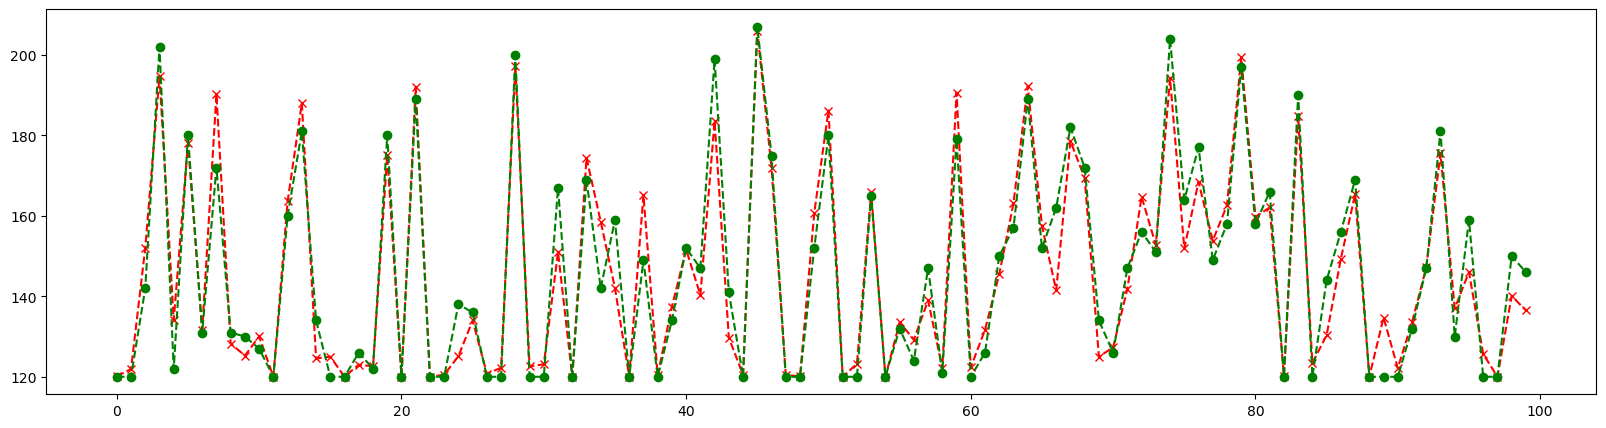

In [28]:
import matplotlib.pyplot as plt
df2 = pd.DataFrame()
df2["y_test"] = y_test
df2["predicted"] = predicted
df2.reset_index(inplace=True)
plt.figure(figsize=(20, 5))
plt.plot(df2["predicted"][:100], marker='x', linestyle='dashed', color='red')
plt.plot(df2["y_test"][:100],  marker='o', linestyle='dashed', color='green')
plt.show()

In [29]:
import joblib
joblib.dump(RFR, 'IPL2.pkl')

['IPL2.pkl']